In [1]:
import pandas as pd, numpy as np

In [5]:
df = pd.read_csv("ai_job_trends_dataset.csv", encoding='latin1')
df.head()

,Job Title,Industry,Job Status,AI Impact Level,Median Salary (USD),Required Education,Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Location,Gender Diversity (%)
0,Investment analyst,IT,Increasing,Moderate,42109.76,Masterâs Degree,5,1515,6342,55.96,28.28,UK,44.63
1,"Journalist, newspaper",Manufacturing,Increasing,Moderate,132298.57,Masterâs Degree,15,1243,6205,16.81,89.71,USA,66.39
2,Financial planner,Finance,Increasing,Low,143279.19,Bachelorâs Degree,4,3338,1154,91.82,72.97,Canada,41.13
3,Legal secretary,Healthcare,Increasing,High,97576.13,Associate Degree,15,7173,4060,1.89,99.94,Australia,65.76
4,Aeronautical engineer,IT,Increasing,Low,60956.63,Masterâs Degree,13,5944,7396,53.76,37.65,Germany,72.57


In [7]:
print(df.columns)

Index(['Job Title', 'Industry', 'Job Status', 'AI Impact Level',
       'Median Salary (USD)', 'Required Education',
       'Experience Required (Years)', 'Job Openings (2024)',
       'Projected Openings (2030)', 'Remote Work Ratio (%)',
       'Automation Risk (%)', 'Location', 'Gender Diversity (%)'],
      dtype='object')


In [11]:
df.columns = df.columns.str.lower().str.replace(" ", "_").str.replace("(", "").str.replace(")", "").str.replace("%", "percent")
df.head(2)

,job_title,industry,job_status,ai_impact_level,median_salary_usd,required_education,experience_required_years,job_openings_2024,projected_openings_2030,remote_work_ratio_percent,automation_risk_percent,location,gender_diversity_percent
0,Investment analyst,IT,Increasing,Moderate,42109.76,Masterâs Degree,5,1515,6342,55.96,28.28,UK,44.63
1,"Journalist, newspaper",Manufacturing,Increasing,Moderate,132298.57,Masterâs Degree,15,1243,6205,16.81,89.71,USA,66.39


In [15]:
df['required_education'] = df['required_education'].str.replace("â€™", "'", regex=True)
df['required_education'].head()

0      Masterâs Degree
1      Masterâs Degree
2    Bachelorâs Degree
3       Associate Degree
4      Masterâs Degree
Name: required_education, dtype: object

In [17]:
df['required_education'] = df['required_education'].apply(
    lambda x: x.encode('latin1').decode('utf-8') if isinstance(x, str) else x
)

In [19]:
df['required_education'].unique()

array(['Master’s Degree', 'Bachelor’s Degree', 'Associate Degree',
       'High School', 'PhD'], dtype=object)

In [21]:
cols = [
    'median_salary_usd',
    'experience_required_years',
    'job_openings_2024',
    'projected_openings_2030',
    'remote_work_ratio_percent',
    'automation_risk_percent',
    'gender_diversity_percent'
]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [27]:
df['growth_rate'] = ((df['projected_openings_2030'] - df['job_openings_2024']) / df['job_openings_2024']) * 100


In [29]:
df['risk_category'] = pd.cut(
    df['automation_risk_percent'],
    bins=[0, 40, 70, 100],
    labels=["Low", "Medium", "High"]
)

In [31]:
df.describe()

,median_salary_usd,experience_required_years,job_openings_2024,projected_openings_2030,remote_work_ratio_percent,automation_risk_percent,gender_diversity_percent,growth_rate
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,90119.965639,10.051433,5039.640833,5074.218100,49.836431,50.154229,49.979660,141.035228
std,34412.013953,6.060678,2861.009654,2866.550722,28.966688,28.754889,17.274665,556.652294
min,30001.860000,0.000000,100.000000,100.000000,0.000000,0.000000,20.000000,-98.937049
25%,60500.702500,5.000000,2570.000000,2586.750000,24.570000,25.400000,35.070000,-49.366518
50%,90274.115000,10.000000,5034.000000,5106.500000,49.570000,50.020000,49.885000,0.303838
75%,119454.710000,15.000000,7527.000000,7573.000000,75.100000,75.030000,64.910000,97.583130
max,149998.500000,20.000000,10000.000000,10000.000000,100.000000,99.990000,80.000000,8945.098039


In [33]:
df.groupby('job_status')['median_salary_usd'].mean()

job_status
Decreasing    90087.161471
Increasing    90152.180303
Name: median_salary_usd, dtype: float64

In [35]:
df.groupby('risk_category')['median_salary_usd'].mean()

C:\Users\HP\AppData\Local\Temp\ipykernel_54612\2026618453.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('risk_category')['median_salary_usd'].mean()


risk_category
Low       89659.079734
Medium    90533.504252
High      90317.711519
Name: median_salary_usd, dtype: float64

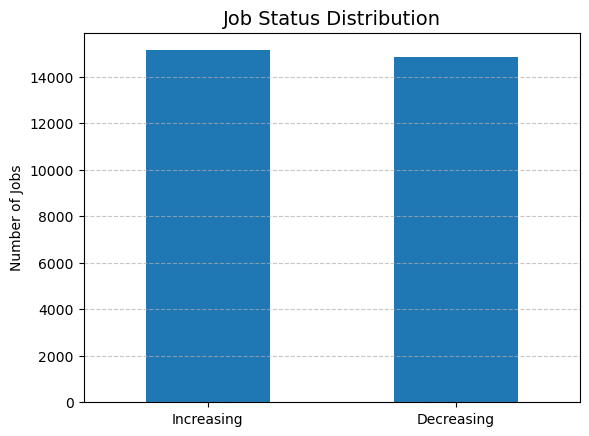

In [45]:
import matplotlib.pyplot as plt

df['job_status'].value_counts().plot(kind='bar')

plt.title("Job Status Distribution", fontsize=14)
plt.xlabel("")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

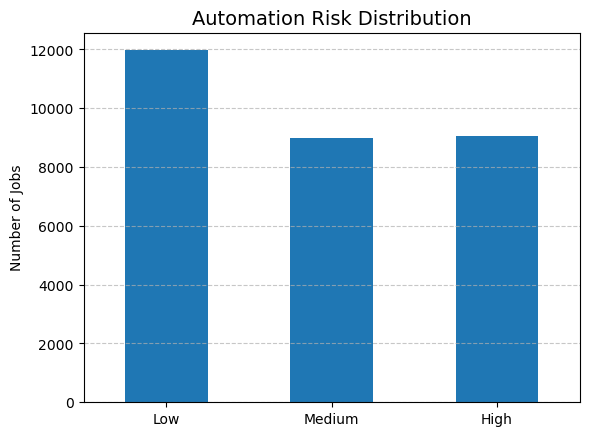

In [47]:
df['risk_category'].value_counts().reindex(['Low','Medium','High']).plot(kind='bar')

plt.title("Automation Risk Distribution", fontsize=14)
plt.xlabel("")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

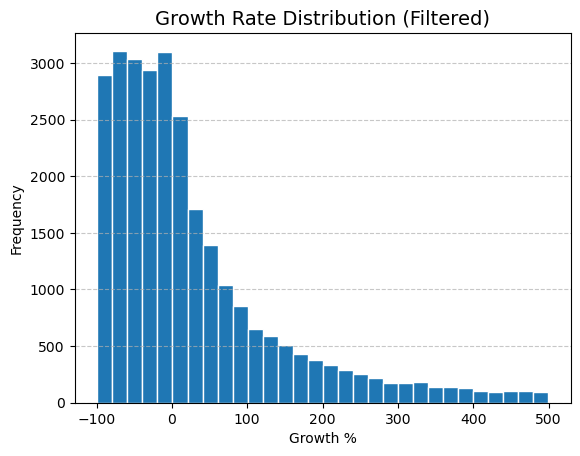

In [53]:
df[df['growth_rate'] < 500]['growth_rate'].plot(kind='hist', bins=30, edgecolor = "white")

plt.title("Growth Rate Distribution (Filtered)", fontsize=14)
plt.xlabel("Growth %")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

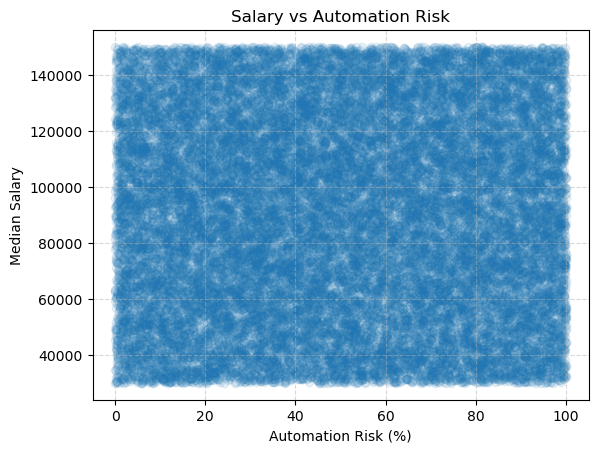

In [59]:
plt.scatter(df['automation_risk_percent'], df['median_salary_usd'], alpha=0.1)

plt.xlabel("Automation Risk (%)")
plt.ylabel("Median Salary")
plt.title("Salary vs Automation Risk")

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_54612\1955811724.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('risk_category')['median_salary_usd'].mean().plot(kind='bar')


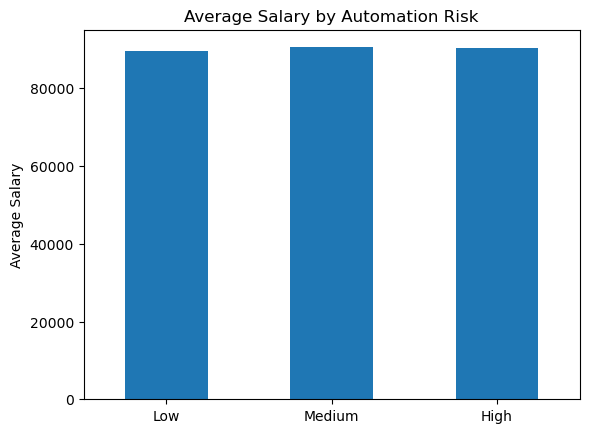

In [61]:
df.groupby('risk_category')['median_salary_usd'].mean().plot(kind='bar')

plt.title("Average Salary by Automation Risk")
plt.xlabel("")
plt.ylabel("Average Salary")
plt.xticks(rotation=0)

plt.show()

In [63]:
df.to_csv("cleaned_ai_jobs.csv", index=False)